In [ ]:
#IPL match analysis using python's pandas library
import pandas as pd

In [3]:
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')
#print(deliveries)
#print(matches)

In [4]:
print("Matches number of missing values: ", matches.isnull().sum())
print("\n Deliveries missing values : ", deliveries.isnull().sum())

Matches number of missing values:  id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

 Deliveries missing values :  match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder  

In [5]:

matches['city'] = matches['city'].fillna('Unknown')
matches['player_of_match'] = matches['player_of_match'].fillna('None')
matches['winner'] = matches['winner'].fillna('No Result')
matches['result_margin'] = matches['result_margin'].fillna(0)
matches['target_runs'] = matches['target_runs'].fillna(0)
matches['target_overs'] = matches['target_overs'].fillna(0)
matches['method'] = matches['method'].fillna('Normal')


deliveries['extras_type'] = deliveries['extras_type'].fillna('None')
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna('None')
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('None')
deliveries['fielder'] = deliveries['fielder'].fillna('None')

In [6]:
print(matches.isnull().sum())
print(deliveries.isnull().sum())

id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64
match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64


In [7]:
#stage 3
(deliveries['batsman_runs'] + deliveries['extra_runs'] == deliveries['total_runs']).all()
deliveries['runs_per_ball'] = deliveries['batsman_runs'] + deliveries['extra_runs']

In [8]:
matches.columns = matches.columns.str.lower()
deliveries.columns = deliveries.columns.str.lower()
matches.rename(columns={'id':'match_id'}, inplace=True)
df = deliveries.merge(matches, on = 'match_id', how = 'left')






In [9]:
print(df.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder', 'runs_per_ball', 'season', 'city', 'date',
       'match_type', 'player_of_match', 'venue', 'team1', 'team2',
       'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin',
       'target_runs', 'target_overs', 'super_over', 'method', 'umpire1',
       'umpire2'],
      dtype='str')


In [10]:
#stage 4
#4.1
runs_per_match = df.groupby('match_id')['total_runs'].sum()
#print(runs_per_match)
#4.2
runs_per_team_match = df.groupby(['match_id', 'batting_team'])['total_runs'].sum()
#print(runs_per_team_match)

#4.3
top_batters = (
    df.groupby('batter')['batsman_runs'].sum()
    .sort_values(ascending=False)
    .head(10)


)
#print(top_batters)
#4.4
# strike_rate  = (
#     df.groupby('batter')['batsman_runs'].sum() / df.groupby('batter')['ball'].count()
    
    
# )*100
# print(strike_rate)

valid_balls = df[df['extras_type'] != 'wides']
strike_rate = (
    valid_balls.groupby('batter')
      .agg({
          'batsman_runs': 'sum',
          'ball' : 'count'
      })
)


strike_rate['strike_rate'] = (
    strike_rate['batsman_runs'] / strike_rate['ball']

) * 100

#print(strike_rate)

#4.5
economy = (
    valid_balls.groupby('bowler')
        .agg({
            'total_runs' : 'sum',
            'ball': 'count'
        })
)

economy['economy'] = (
    economy['total_runs'] / (economy['ball']/6)
                      )

#print(economy)

#4.6
batter_match_runs = (
    df.groupby(['batter', 'match_id'])['batsman_runs']
    .sum()
    .reset_index()
)

batter_stats = (
    batter_match_runs.groupby('batter')
        .agg({
            'batsman_runs':'mean',
            'match_id':'nunique'
        })
        .rename(columns={
            'batsman_runs':'avg_runs_per_match',
            'match_id':'matches_played'
        })
)

consistent_batters = batter_stats[batter_stats['matches_played'] >= 30]

consistent_batters = consistent_batters.sort_values(
    by='avg_runs_per_match',
    ascending=False
).head(10)
#print(consistent_batters)

#4.7
top_batter_match_runs = (
    df.groupby(['batter', 'match_id'])['batsman_runs'].sum().reset_index()
)
top_batter_match_runs_sorted = top_batter_match_runs.sort_values(
    by='batsman_runs',
    ascending=False
).head(1)

#print(top_batter_match_runs_sorted)
#4.8



In [11]:
boundaries = valid_balls[(valid_balls['batsman_runs'] == 4) | (valid_balls['batsman_runs'] == 6)]
boundary_counts = boundaries.groupby('batter').agg({
        'ball':'count',
    }).rename(columns={'ball': 'boundary_count'})
#better version :- boundary_counts = boundaries.groupby('batter').size().reset_index(name='boundary_count')
#print(boundary_counts)
top_battter_boundaries = boundary_counts.sort_values(
    by='boundary_count',
    ascending=False,
    
).head(10)
#print(top_battter_boundaries)
total_boundaries = boundary_counts.agg({
    'boundary_count':'sum'
})
#better version:- total_boundaries = boundary_counts['boundary_count'].sum()
print(total_boundaries)

boundary_count    42901
dtype: int64


In [12]:
#4.9
boundary_runs = boundaries['batsman_runs'].sum()
print(boundary_runs)

total_runs = df['total_runs'].sum()
print(total_runs)
percentage_answer = (boundary_runs / total_runs) * 100
print(percentage_answer)

197706
347756
56.85193066402881


In [13]:
#4.10
dot_balls = df[df['total_runs'] == 0]
print(len(dot_balls))
#print(dot_balls)
player_dot_balls = dot_balls.groupby('bowler').agg({
    'ball' : 'count'
})



player_dot_balls_sorted = player_dot_balls.sort_values(
    by='ball',
    ascending=False,

).head(10)

print(player_dot_balls_sorted)





90438
                 ball
bowler               
B Kumar          1632
SP Narine        1569
R Ashwin         1552
PP Chawla        1325
Harbhajan Singh  1263
JJ Bumrah        1228
RA Jadeja        1216
YS Chahal        1194
UT Yadav         1186
A Mishra         1185


In [14]:
#4.11
over_runs = df.groupby('over')['total_runs'].sum()
print(over_runs)
over_runs_avg = (
    df.groupby(['match_id', 'over'])['total_runs']
      .sum()
      .groupby('over')
      .mean()
)

print(over_runs_avg)

over
0     13651
1     16163
2     17895
3     18415
4     18565
5     18528
6     14839
7     15981
8     16639
9     16353
10    16779
11    17076
12    17205
13    17634
14    18149
15    18472
16    19012
17    19559
18    19076
19    17765
Name: total_runs, dtype: int64
over
0     12.466667
1     14.760731
2     16.342466
3     16.817352
4     16.954338
5     16.936015
6     13.563985
7     14.607861
8     15.223239
9     14.961574
10    15.379468
11    15.694853
12    15.842541
13    16.252535
14    16.727189
15    17.056325
16    17.669145
17    18.245336
18    17.979265
19    16.967526
Name: total_runs, dtype: float64


In [15]:
#4.12
powerplay_overs = df[(df['over'] >= 1) & (df['over'] <= 6)]
#print(powerplay_overs)
runs_powerplay = powerplay_overs['total_runs'].sum()
#print(runs_powerplay)
powerplay_overs_teams = powerplay_overs.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
print(powerplay_overs_teams)



batting_team
Mumbai Indians                 12371
Kolkata Knight Riders          11912
Chennai Super Kings            11379
Royal Challengers Bangalore    10929
Rajasthan Royals               10333
Kings XI Punjab                 9095
Sunrisers Hyderabad             9047
Delhi Daredevils                7506
Delhi Capitals                  4706
Deccan Chargers                 3407
Punjab Kings                    2885
Gujarat Titans                  2216
Lucknow Super Giants            2140
Pune Warriors                   1877
Gujarat Lions                   1609
Royal Challengers Bengaluru      869
Rising Pune Supergiant           786
Rising Pune Supergiants          672
Kochi Tuskers Kerala             666
Name: total_runs, dtype: int64


In [16]:
#4.13
death_overs = df[(df['over'] >= 16) & (df['over'] <= 20)]
#print(powerplay_overs)
runs_death = death_overs['total_runs'].sum()
#print(runs_powerplay)
death_overs_teams = death_overs.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
print(death_overs_teams)


batting_team
Mumbai Indians                 9598
Chennai Super Kings            9061
Royal Challengers Bangalore    8417
Kolkata Knight Riders          8053
Rajasthan Royals               7281
Sunrisers Hyderabad            6237
Kings XI Punjab                6227
Delhi Daredevils               5043
Delhi Capitals                 3141
Deccan Chargers                2539
Punjab Kings                   2047
Gujarat Titans                 1823
Lucknow Super Giants           1718
Pune Warriors                  1360
Gujarat Lions                   921
Royal Challengers Bengaluru     611
Rising Pune Supergiant          555
Rising Pune Supergiants         443
Kochi Tuskers Kerala            337
Name: total_runs, dtype: int64


In [17]:
#4.14
df_filtered = df[df['inning'].isin([1,2])]
runs_per_inning = (
    df_filtered.groupby('inning')['total_runs'].sum()
)
avg_runs_per_inning = (
    df_filtered.groupby(['match_id', 'inning'])['total_runs']
    .sum()
    .groupby('inning')
    .mean()
)
print(avg_runs_per_inning)



inning
1    165.547032
2    152.194139
Name: total_runs, dtype: float64


In [18]:
team_runs = (
    df.groupby(['match_id', 'batting_team'])['total_runs']
    .sum()
    .reset_index()
    .rename(columns={'total_runs': 'team_runs'})
)

match_info = df[['match_id', 'toss_winner', 'team1', 'team2']].drop_duplicates()

team_runs = team_runs.merge(match_info, on='match_id', how='left')

team_runs['opponent'] = team_runs.apply(
    lambda x: x['team2'] if x['batting_team'] == x['team1'] else x['team1'],
    axis=1
)

team_runs['is_toss_winner'] = (
    team_runs['batting_team'] == team_runs['toss_winner']
)

toss_analysis = (
    team_runs.groupby('is_toss_winner')['team_runs']
    .mean()
)

print(toss_analysis)

is_toss_winner
False    161.351920
True     156.666972
Name: team_runs, dtype: float64


In [19]:
#4.16
batter_match_runs = (
    df.groupby(['match_id', 'batter'])['batsman_runs']
    .sum()
    .reset_index()
)

In [20]:
#17
matches_per_venue = matches.groupby('venue')['match_id'].count()
print(matches_per_venue)

venue
Arun Jaitley Stadium                                                     14
Arun Jaitley Stadium, Delhi                                              16
Barabati Stadium                                                          7
Barsapara Cricket Stadium, Guwahati                                       3
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow    14
Brabourne Stadium                                                        10
Brabourne Stadium, Mumbai                                                17
Buffalo Park                                                              3
De Beers Diamond Oval                                                     3
Dr DY Patil Sports Academy                                               17
Dr DY Patil Sports Academy, Mumbai                                       20
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium                      13
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam        2
Dubai 

In [21]:

runs_per_match = deliveries.groupby('match_id')['total_runs'].sum()


match_runs = matches[['match_id', 'venue']].merge(
    runs_per_match,
    on='match_id'
)

avg_runs_venue = match_runs.groupby('venue')['total_runs'].mean()
print(avg_runs_venue)

venue
Arun Jaitley Stadium                                                     324.500000
Arun Jaitley Stadium, Delhi                                              380.687500
Barabati Stadium                                                         325.428571
Barsapara Cricket Stadium, Guwahati                                      339.666667
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow    306.714286
Brabourne Stadium                                                        348.100000
Brabourne Stadium, Mumbai                                                342.588235
Buffalo Park                                                             266.333333
De Beers Diamond Oval                                                    299.000000
Dr DY Patil Sports Academy                                               282.941176
Dr DY Patil Sports Academy, Mumbai                                       328.650000
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium                   

In [ ]:
#18

match_runs_city = matches[['match_id', 'city']].merge(
    runs_per_match, on='match_id'
)

avg_runs_city = match_runs_city.groupby('city')['total_runs'].mean()
print(avg_runs_city)

high_scoring_cities = avg_runs_city.sort_values(ascending=False).head(5)
print(high_scoring_cities)

city
Abu Dhabi         306.270270
Ahmedabad         331.027778
Bangalore         311.738462
Bengaluru         360.310345
Bloemfontein      264.500000
Cape Town         256.714286
Centurion         304.416667
Chandigarh        325.639344
Chennai           314.188235
Cuttack           325.428571
Delhi             322.833333
Dharamsala        339.384615
Dubai             306.846154
Durban            290.200000
East London       266.333333
Guwahati          339.666667
Hyderabad         315.090909
Indore            319.111111
Jaipur            310.263158
Johannesburg      286.500000
Kanpur            324.500000
Kimberley         299.000000
Kochi             272.600000
Kolkata           319.817204
Lucknow           306.714286
Mohali            335.000000
Mumbai            328.421965
Nagpur            294.000000
Navi Mumbai       318.333333
Port Elizabeth    290.428571
Pune              306.725490
Raipur            290.166667
Rajkot            333.300000
Ranchi            293.714286
Sharjah  

In [24]:
#19
match_runs_season = matches[['match_id', 'season']].merge(
    runs_per_match, on='match_id'
)

runs_per_season = match_runs_season.groupby('season')['total_runs'].sum()
print(runs_per_season)

season
2007/08    17937
2009       16353
2009/10    18883
2011       21154
2012       22453
2013       22602
2014       18931
2015       18353
2016       18862
2017       18786
2018       19901
2019       19434
2020/21    19416
2021       18637
2022       24395
2023       25688
2024       25971
Name: total_runs, dtype: int64


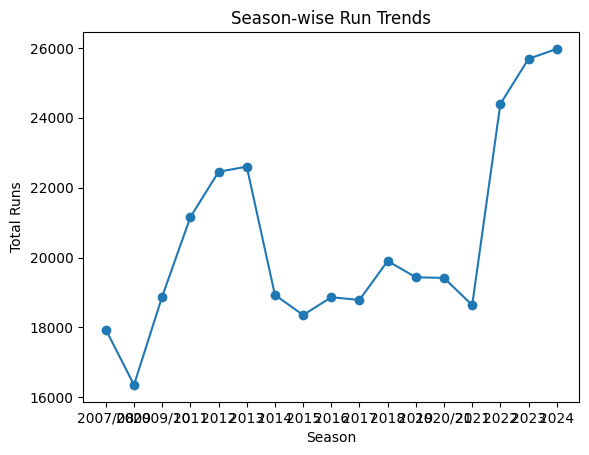

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(runs_per_season.index, runs_per_season.values, marker='o')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.title('Season-wise Run Trends')
plt.show()

In [ ]:
#20
team_runs = deliveries.groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()
predicted_winners = {}

for match_id, group in team_runs.groupby('match_id'):
    winner = group.loc[group['total_runs'].idxmax(), 'batting_team']
    predicted_winners[match_id] = winner

In [29]:
matches['predicted_winner'] = matches['match_id'].map(predicted_winners)

accuracy = (matches['winner'] == matches['predicted_winner']).mean()
print(f"Prediction Accuracy: {accuracy * 100:.2f}%")

Prediction Accuracy: 98.26%
